Class balance:
 is_setosa
0    100
1     50
Name: count, dtype: int64

=== Evaluation ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000

=== Model Coefficients (log-odds) ===
  sepal_length  : -0.9206
  sepal_width   :  1.3185
  petal_length  : -1.6397
  petal_width   : -1.5493
  Intercept     : -2.3231

=== Odds Ratios (per 1 std-dev increase) ===
  sepal_length  :  0.3983
  sepal_width   :  3.7377
  petal_length  :  0.1940
  petal_width   :  0.2124


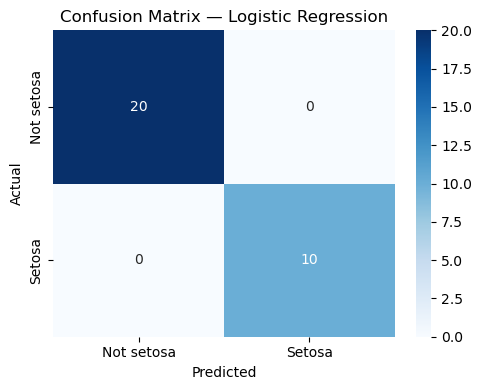


Classification Report:
              precision    recall  f1-score   support

  Not setosa       1.00      1.00      1.00        20
      Setosa       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



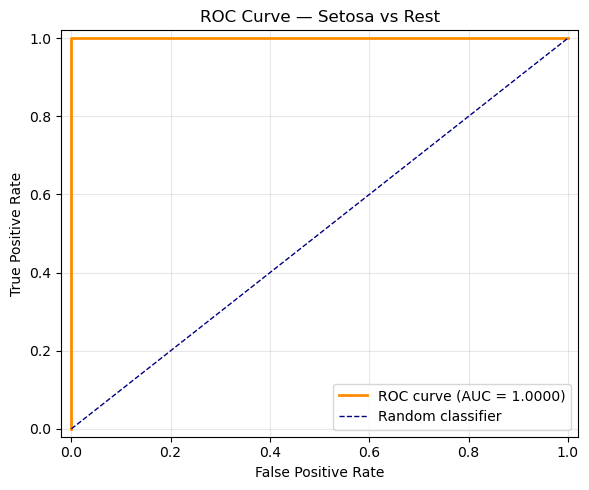

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# ---------------------------------------------------------
# 1. Load dataset
# ---------------------------------------------------------
df = pd.read_csv(r"C:\Users\250 G7\Desktop\CodeVeda Intern\Dataset\1) iris.csv")

# Binary target: setosa vs rest
df["is_setosa"] = (df["species"] == "setosa").astype(int)
print("Class balance:\n", df["is_setosa"].value_counts())

# ---------------------------------------------------------
# 2. Features and target
# ---------------------------------------------------------
feature_names = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = df[feature_names]
y = df["is_setosa"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------------------
# 3. Scale features
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 4. Train logistic regression
# ---------------------------------------------------------
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ---------------------------------------------------------
# 5. Evaluation metrics
# ---------------------------------------------------------
print("\n=== Evaluation ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

# ---------------------------------------------------------
# 6. Coefficients and odds ratios
# ---------------------------------------------------------
print("\n=== Model Coefficients (log-odds) ===")
for name, coef in zip(feature_names, model.coef_[0]):
    print(f"  {name:14s}: {coef: .4f}")
print(f"  {'Intercept':14s}: {model.intercept_[0]: .4f}")

print("\n=== Odds Ratios (per 1 std-dev increase) ===")
odds = np.exp(model.coef_[0])
for name, o in zip(feature_names, odds):
    print(f"  {name:14s}: {o: .4f}")

# ---------------------------------------------------------
# 7. Confusion matrix
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not setosa", "Setosa"],
            yticklabels=["Not setosa", "Setosa"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Not setosa", "Setosa"]))

# ---------------------------------------------------------
# 8. ROC curve
# ---------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--",
         label="Random classifier")
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Setosa vs Rest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()